# Projekat: Klasifikacija pecuraka (Edible vs Poisinous)
**Tema**: Nadgledano ucenje - Klasifikacija

**Dataset**: [Mushroom Classification (Kaggle - Biology)](https://www.kaggle.com/datasets/uciml/mushroom-classification)

## Definicija problema i ucitavanje podataka
### Cilj: Na osnovu fizickih karakteristika pecurke predvideti da li je otrovna ili jestiva.

### Ucitavanje biblioteka i skupa podataka.


In [1634]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
warnings.filterwarnings("ignore")

In [1635]:
df = pd.read_csv('data/mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Opis atributa 

- <b>class</b>: Klasa (Cilj): edible=e (jestiva), poisonous=p (otrovna)

- <b>cap-shape</b>: Oblik sesira: bell=b (zvonast), conical=c (kupast), convex=x (ispupcen), flat=f (ravan), knobbed=k (kvrgav/izbocen), sunken=s (udubljen)

- <b>cap-surface</b>: Povrsina sesira: fibrous=f (vlaknasta), grooves=g (zljebovita), scaly=y (ljuspasta), smooth=s (glatka)

- <b>cap-color</b>: Boja sesira: brown=n (braon), buff=b (bez/zutosmedja), cinnamon=c (cimet), gray=g (siva), green=r (zelena), pink=p (roze), purple=u (ljubicasta), red=e (crvena), white=w (bela), yellow=y (zuta)

- <b>bruises</b>: Uboji (modrice/ostecenja): bruises=t (ima), no=f (nema)

- <b>odor</b>: Miris: almond=a (badem), anise=l (anis), creosote=c (kreozot/dim), fishy=y (riba), foul=f (uzasan/trulez), musty=m (budjav), none=n (bez mirisa), pungent=p (ostar/ljut), spicy=s (zacinski)

- <b>gill-attachment</b>: Prianjanje listica (za drsku): attached=a (pripojeni), descending=d (silazni), free=f (slobodni), notched=n (nazubljeni)

- <b>gill-spacing</b>: Razmak listica: close=c (blizu), crowded=w (zbijeni), distant=d (razmaknuti)

- <b>gill-size</b>: Velicina listica: broad=b (siroki), narrow=n (uski)

- <b>gill-color</b>: Boja listica: black=k (crna), brown=n (braon), buff=b (bez), chocolate=h (cokoladna), gray=g (siva), green=r (zelena), orange=o (narandzasta), pink=p (roze), purple=u (ljubicasta), red=e (crvena), white=w (bela), yellow=y (zuta)

- <b>stalk-shape</b>: Oblik drske: enlarging=e (prosiruje se), tapering=t (suzava se)

- <b>stalk-root</b>: Koren drske: bulbous=b (lukovicast), club=c (batinast), cup=u (casast), equal=e (jednak), rhizomorphs=z (rizomorfi/koncici), rooted=r (ukorenjen), missing=? (nepoznato/nedostaje)

- <b>stalk-surface-above-ring</b>: Povrsina drske iznad prstena: fibrous=f (vlaknasta), scaly=y (ljuspasta), silky=k (svilenkasta), smooth=s (glatka)

- <b>stalk-surface-below-ring</b>: Povrsina drske ispod prstena: fibrous=f (vlaknasta), scaly=y (ljuspasta), silky=k (svilenkasta), smooth=s (glatka)

- <b>stalk-color-above-ring</b>: Boja drske iznad prstena: brown=n (braon), buff=b (bez), cinnamon=c (cimet), gray=g (siva), orange=o (narandzasta), pink=p (roze), red=e (crvena), white=w (bela), yellow=y (zuta)

- <b>stalk-color-below-ring</b>: Boja drske ispod prstena: (iste boje kao iznad)

- <b>veil-type</b>: Tip vela: partial=p (delimican), universal=u (univerzalan)

- <b>veil-color</b>: Boja vela: brown=n (braon), orange=o (narandzasta), white=w (bela), yellow=y (zuta)

- <b>ring-number</b>: Broj prstenova: none=n (nema), one=o (jedan), two=t (dva)

- <b>ring-type</b>: Tip prstena: cobwebby=c (paucinast), evanescent=e (nestalan/prolazan), flaring=f (siri se/levkast), large=l (veliki), none=n (nema), pendant=p (viseci), sheathing=s (obavijen), zone=z (zona)

- <b>spore-print-color</b>: Boja spora (otisak): black=k (crna), brown=n (braon), buff=b (bez), chocolate=h (cokoladna), green=r (zelena), orange=o (narandzasta), purple=u (ljubicasta), white=w (bela), yellow=y (zuta)

- <b>population</b>: Populacija (kako rastu): abundant=a (izobilna), clustered=c (grupisana/klasteri), numerous=n (brojna), scattered=s (rastrkana), several=v (nekoliko), solitary=y (usamljena)

- <b>habitat</b>: Staniste: grasses=g (trava), leaves=l (lisce), meadows=m (livade), paths=p (staze), urban=u (urbano), waste=w (otpad), woods=d (suma)

## Deskriptivna analiza i priprema podataka

### Tipovi podataka

In [1636]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

### Provera nedostatka i duplikata

In [1637]:
null_counts = df.isnull().sum()
total_null = null_counts.sum()
print(f"Broj nedostajucih vrednosti u celom datasetu: {total_null}")

dupes = df.duplicated().sum()
print(f"Pronadjeno {dupes} duplikata")

Broj nedostajucih vrednosti u celom datasetu: 0
Pronadjeno 0 duplikata


### Detaljan prikaz atributa u odnosu na klasu (da li je jestiva ili ne)

#### Balans klasa

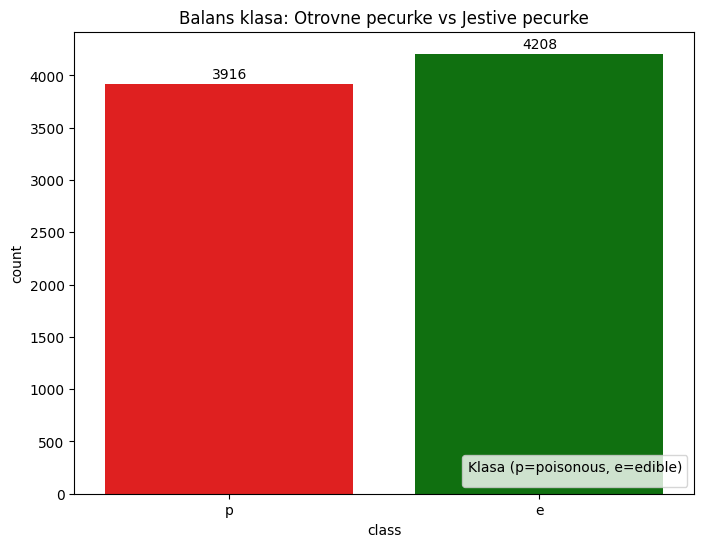

In [1638]:
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    x='class', 
    data=df, 
    hue='class',
    legend=False,
    palette=['red', 'green'] 
)

plt.title('Balans klasa: Otrovne pecurke vs Jestive pecurke')
plt.legend(title='Klasa (p=poisonous, e=edible)', loc='lower right')

for container in ax.containers:
    ax.bar_label(container, padding=2)

plt.show()


#### Distribucija razlicitih cap atributa

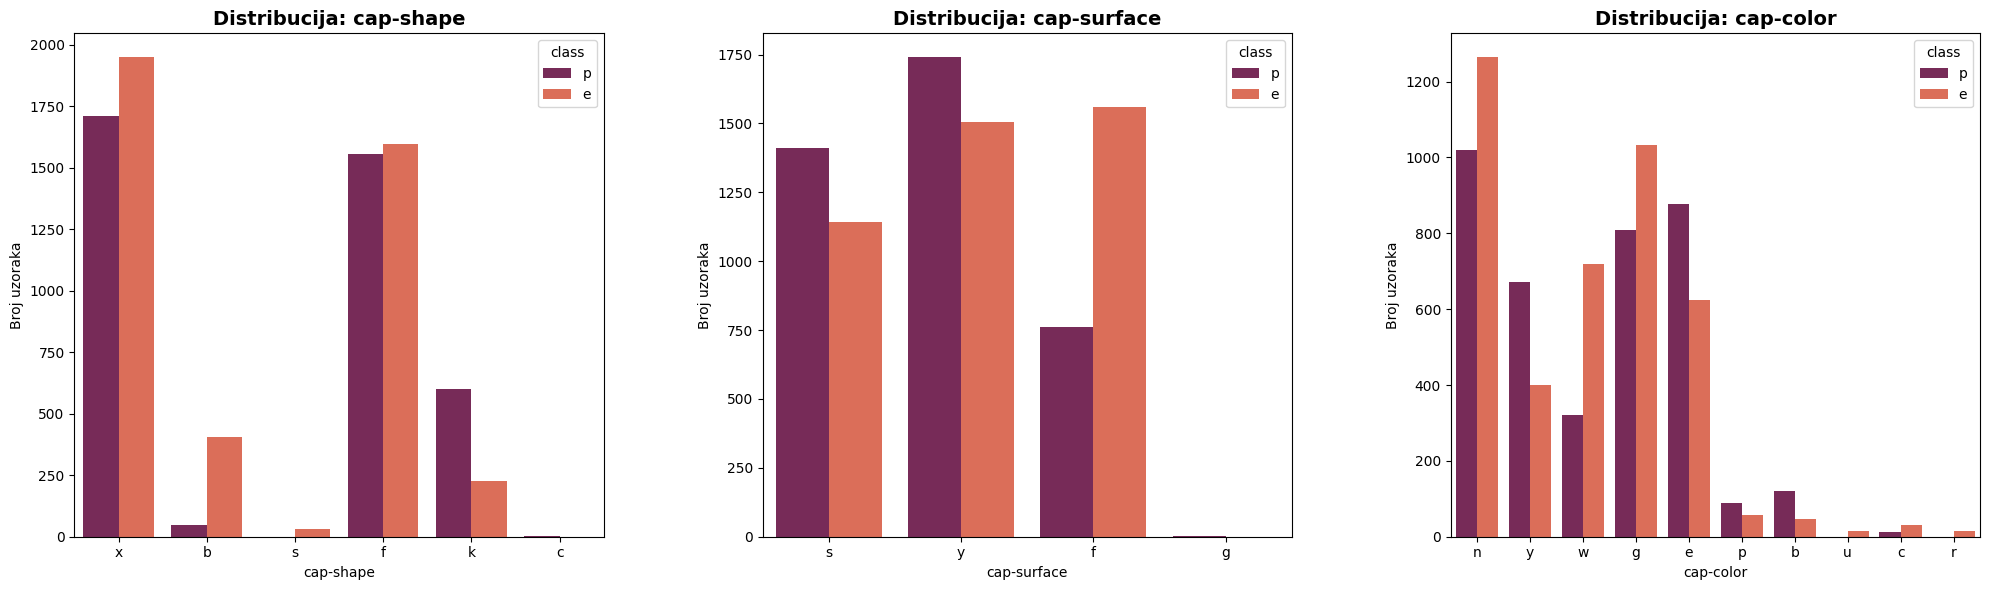

In [1639]:
features = ['cap-shape', 'cap-surface', 'cap-color']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

for i, col in enumerate(features):
    sns.countplot(x=col, hue='class', data=df, palette="rocket", ax=axes[i])
    axes[i].set_title(f'Distribucija: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()

#### Distribucija bruises

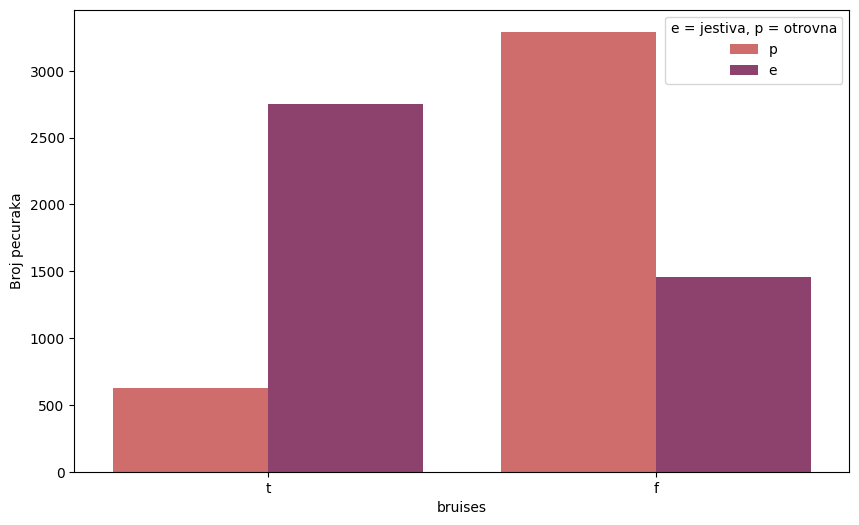

In [1640]:
plt.figure(figsize=(10, 6))

sns.countplot(x='bruises', hue='class', data=df, palette='flare')

plt.ylabel('Broj pecuraka')
plt.legend(title='e = jestiva, p = otrovna', loc='upper right')

plt.show()

#### Distribucija odora

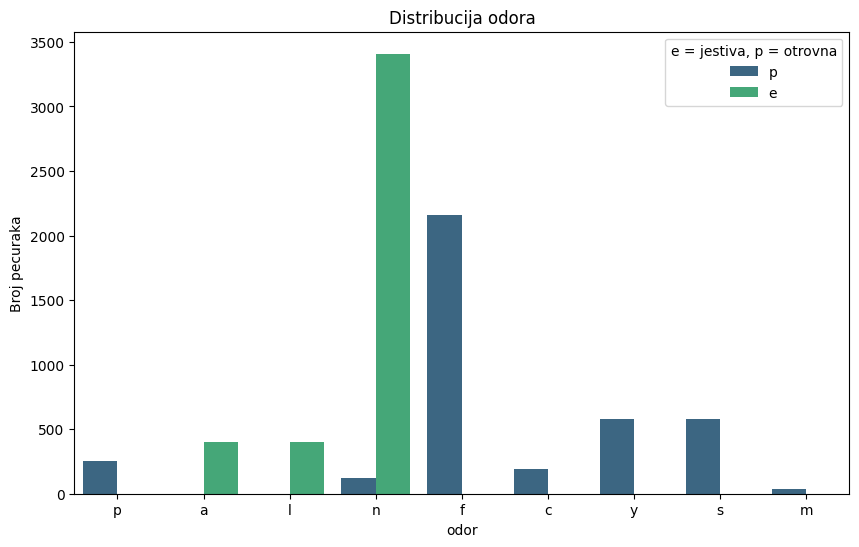

In [1641]:
plt.figure(figsize=(10, 6))

sns.countplot(x='odor', hue='class', data=df, palette='viridis')

plt.title('Distribucija odora')
plt.ylabel('Broj pecuraka')
plt.legend(title='e = jestiva, p = otrovna', loc='upper right')


plt.show()

#### Distribucija gill-attachmenta

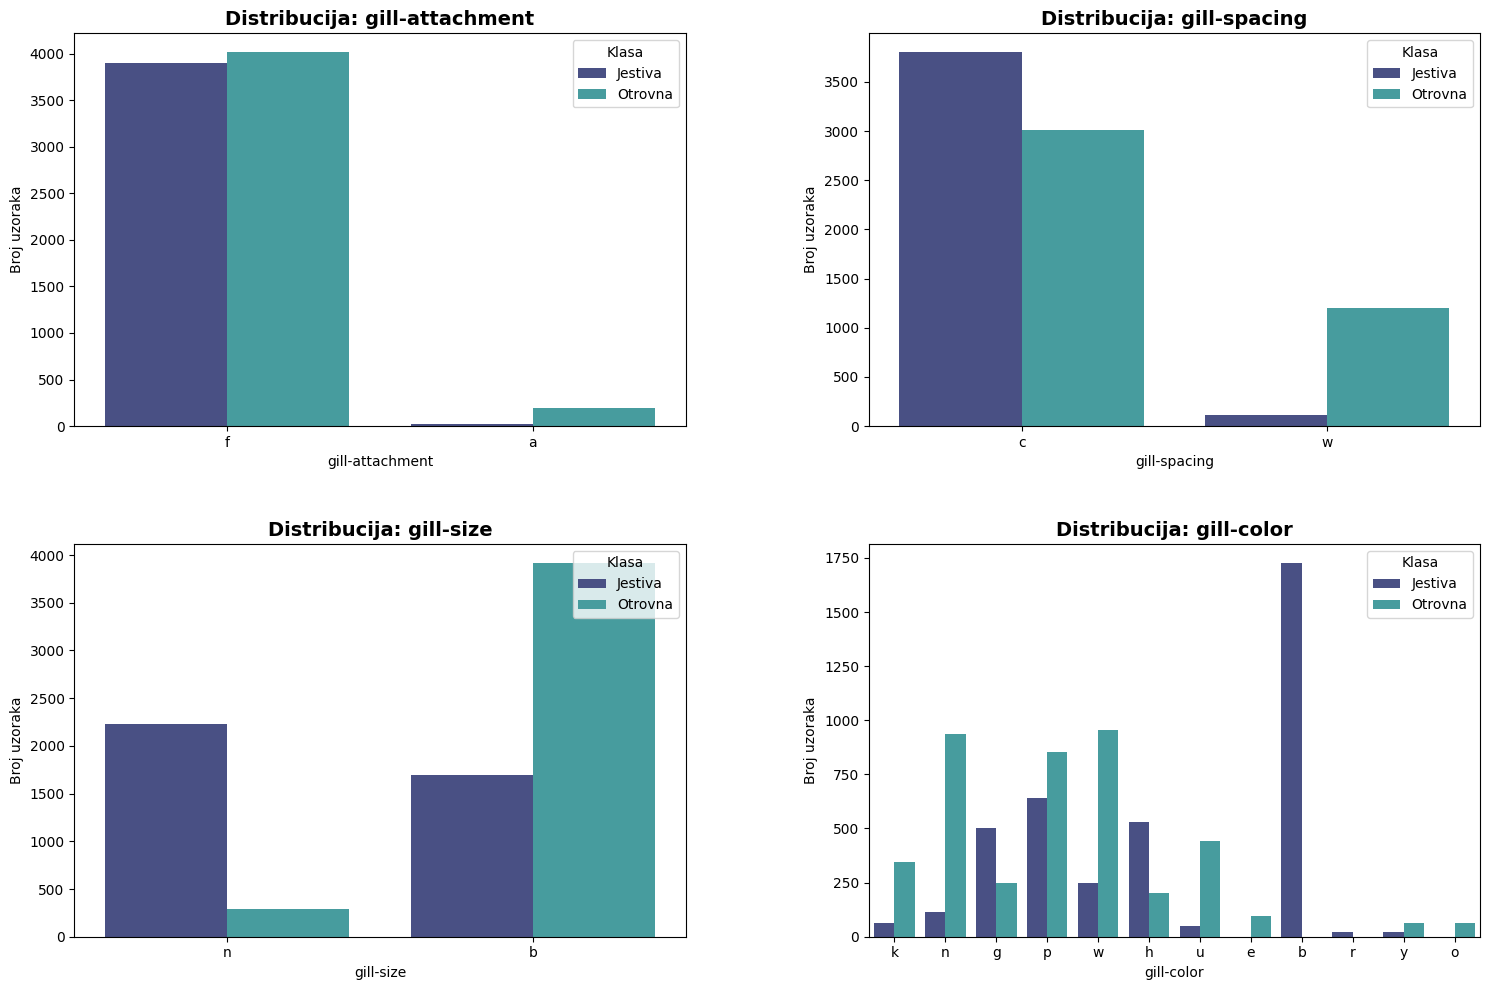

In [1642]:
features = ['gill-attachment', 'gill-spacing', 'gill-size', 'gill-color']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

axes = axes.flatten() 

for i, col in enumerate(features):
    sns.countplot(x=col, hue='class', data=df, palette='mako', ax=axes[i])
    
    axes[i].set_title(f'Distribucija: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].legend(title='Klasa', labels=['Jestiva', 'Otrovna'], loc='upper right')


plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

#### Distribucija korena (stalk)

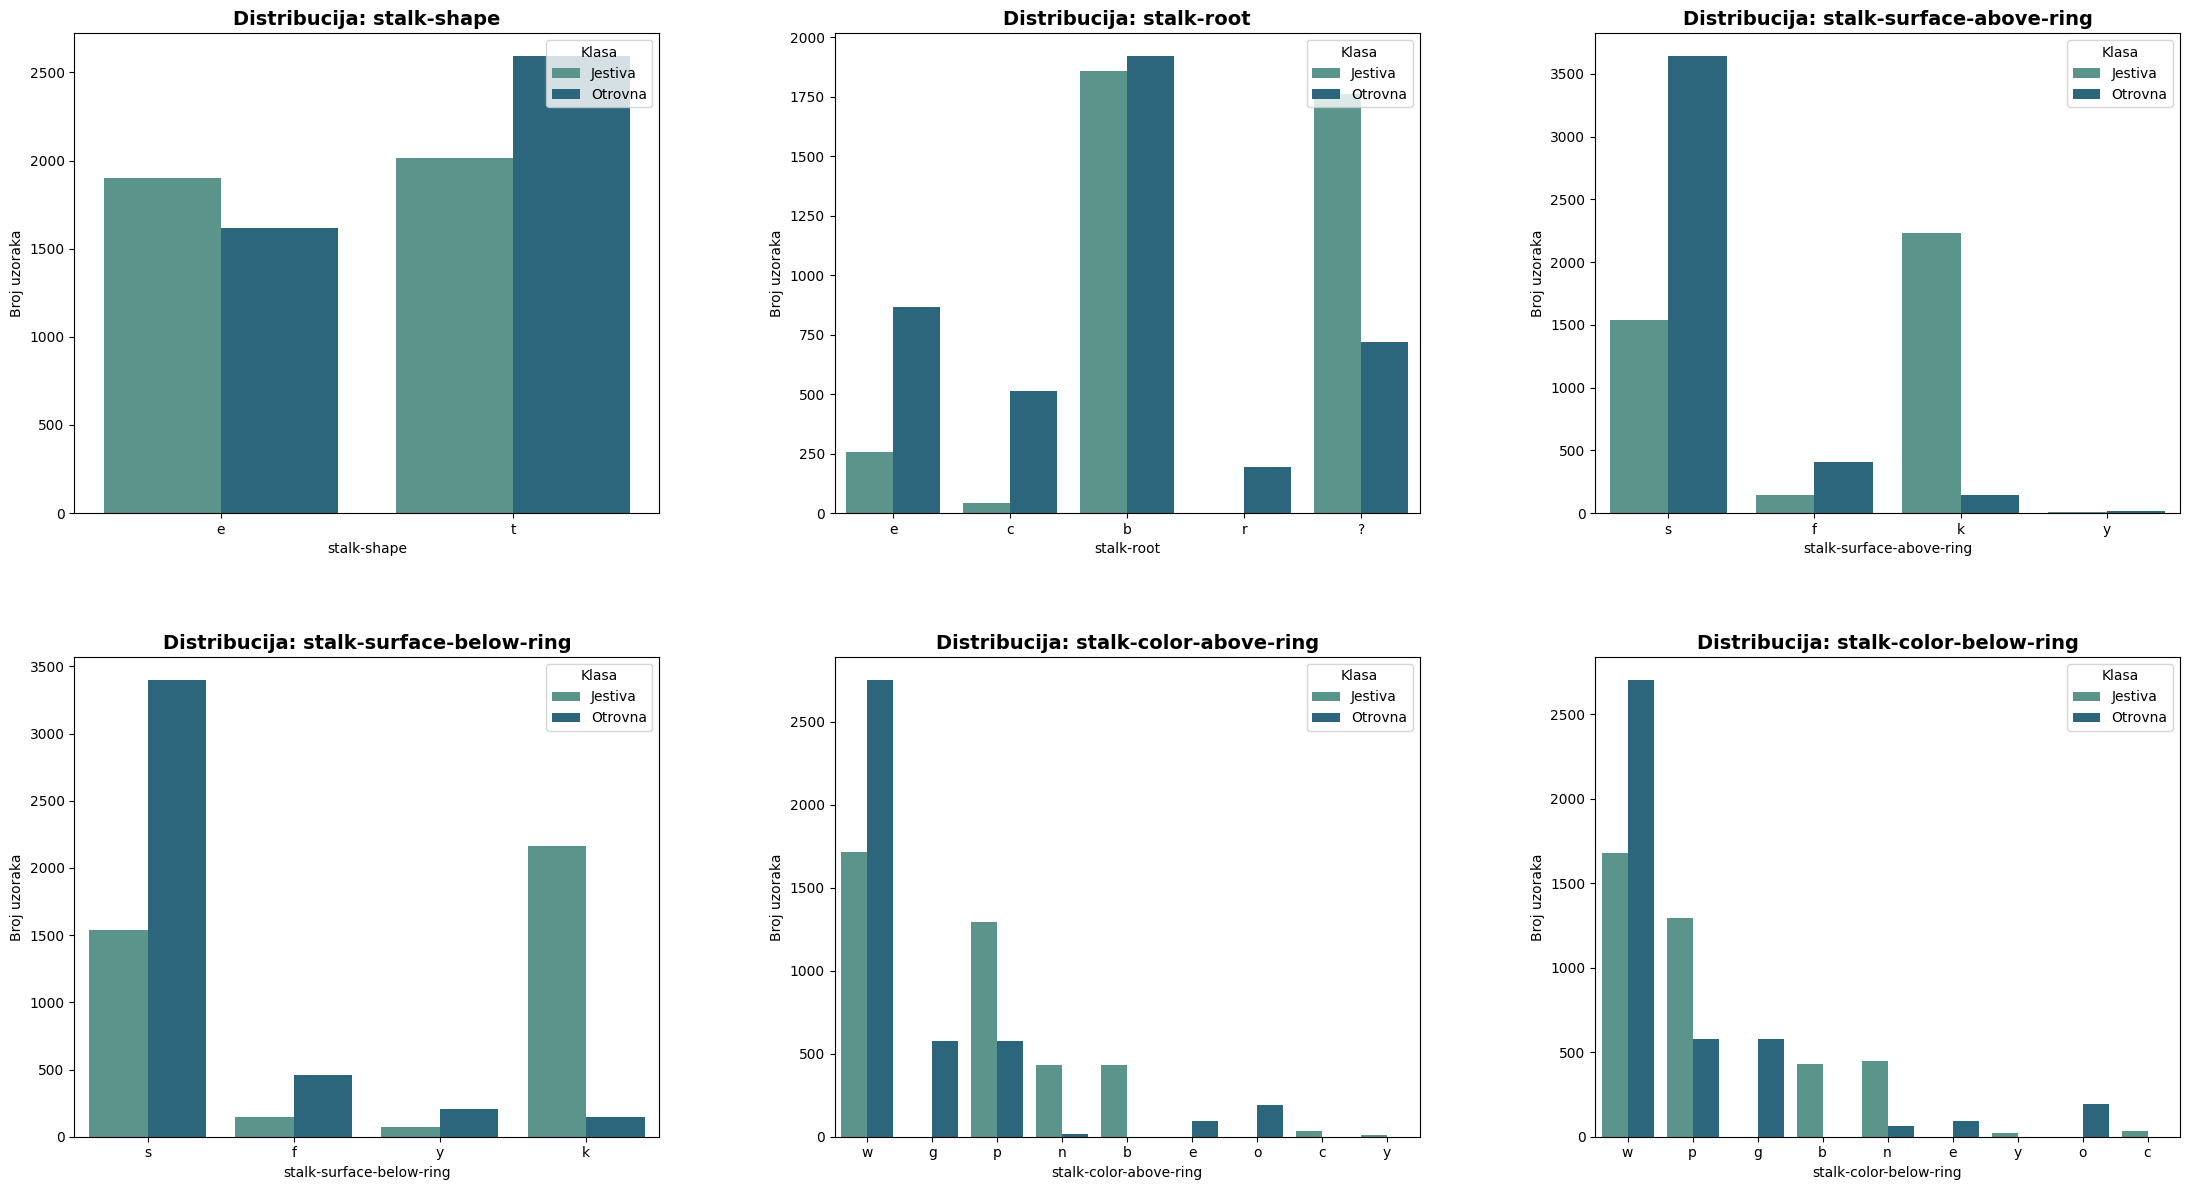

In [1643]:
stalk_features = ['stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(22, 12))

axes = axes.flatten() 

for i, col in enumerate(stalk_features):
    sns.countplot(x=col, hue='class', data=df, palette='crest', ax=axes[i])
    
    axes[i].set_title(f'Distribucija: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].legend(title='Klasa', labels=['Jestiva', 'Otrovna'], loc='upper right')

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

#### Detaljan prikaz samo distribucije vrste korena

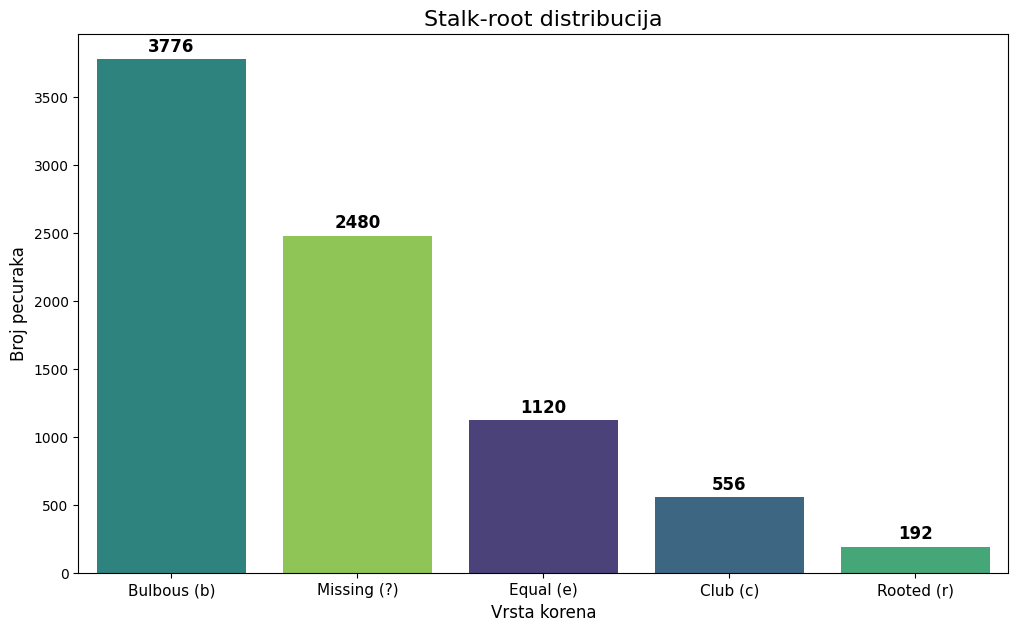

In [1644]:
plt.figure(figsize=(12, 7))

df_viz = df.copy()

mapping = {
    'b': 'Bulbous (b)',
    '?': 'Missing (?)',
    'e': 'Equal (e)',
    'c': 'Club (c)',
    'r': 'Rooted (r)'
}

df_viz['stalk-root'] = df_viz['stalk-root'].map(mapping)

ax = sns.countplot(
    x='stalk-root', 
    data=df_viz, 
    hue='stalk-root',
    legend=False,
    palette='viridis',
    order=df_viz['stalk-root'].value_counts().index
)

for container in ax.containers:
    ax.bar_label(container, fontsize=12, padding=3, fontweight='bold')

plt.title('Stalk-root distribucija', fontsize=16)
plt.xlabel('Vrsta korena', fontsize=12)
plt.ylabel('Broj pecuraka', fontsize=12)
plt.xticks(fontsize=11)

plt.show()

### Zamena ? u "Unknown" radi tehnicke ispravnosti (One-Hot Encoding) i bolje interpretacije modela

In [1645]:
df['stalk-root'] = df['stalk-root'].replace('?', 'Unknown')

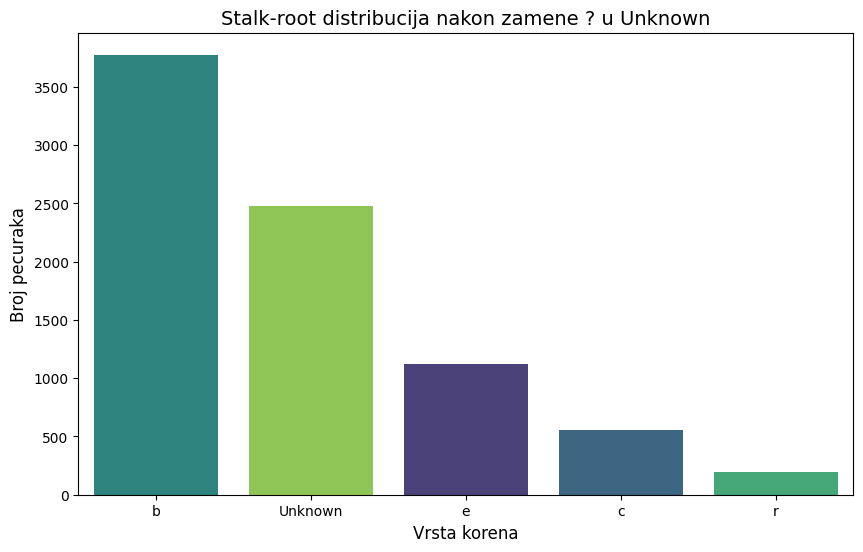

In [1646]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    x='stalk-root',
    data=df,
    hue='stalk-root',
    legend=False,
    palette='viridis',
    order=df['stalk-root'].value_counts().index
)

plt.title('Stalk-root distribucija nakon zamene ? u Unknown', fontsize=14)
plt.xlabel('Vrsta korena', fontsize=12)
plt.ylabel('Broj pecuraka', fontsize=12)

plt.show()

#### Distribucija vela

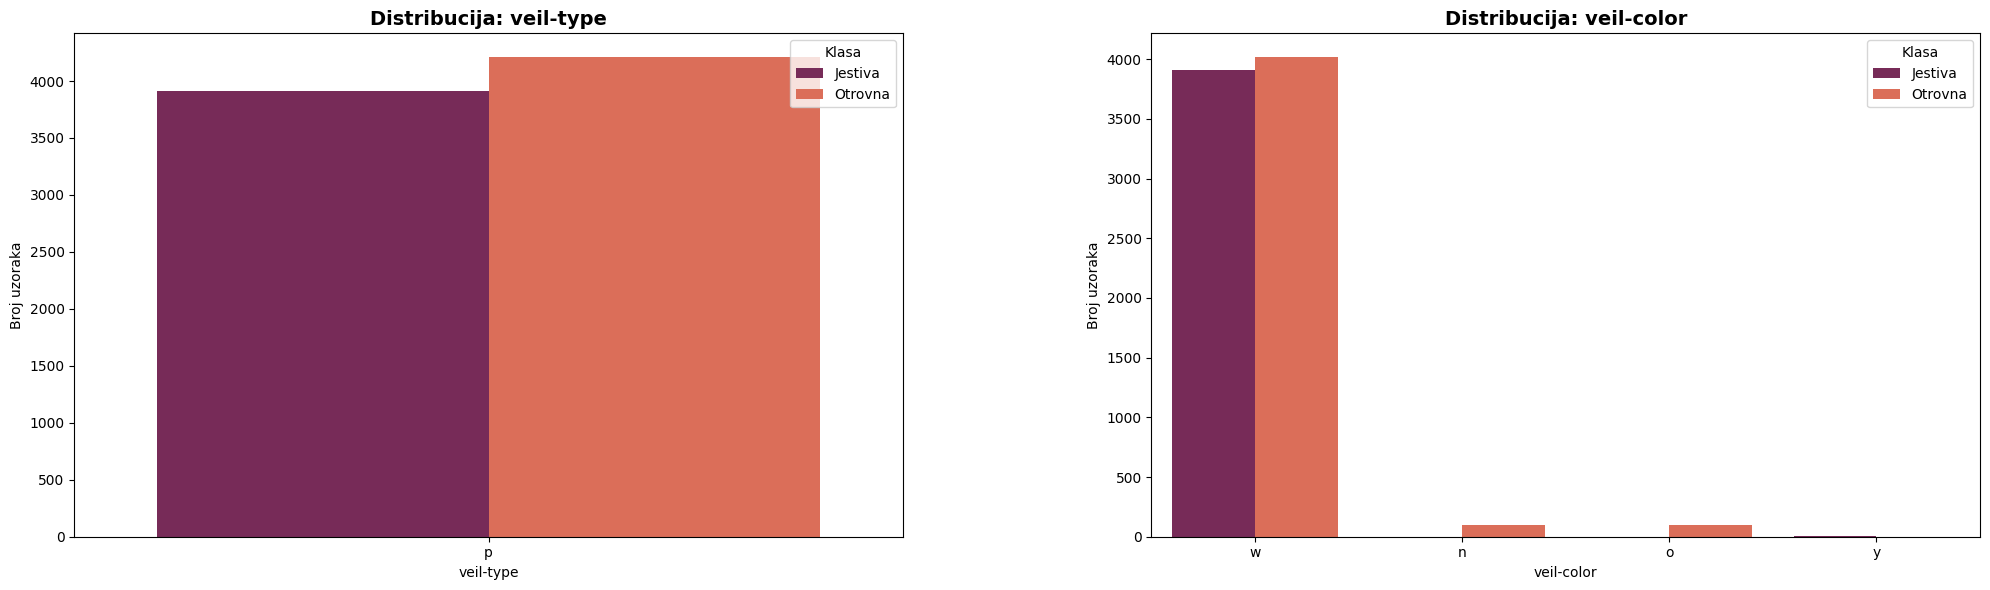

In [1647]:
veil_features = ['veil-type', 'veil-color']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 6))

axes = axes.flatten() 

for i, col in enumerate(veil_features):
    sns.countplot(x=col, hue='class', data=df, palette='rocket', ax=axes[i])
    
    axes[i].set_title(f'Distribucija: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].legend(title='Klasa', labels=['Jestiva', 'Otrovna'], loc='upper right')

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

#### Distribucija prstenova

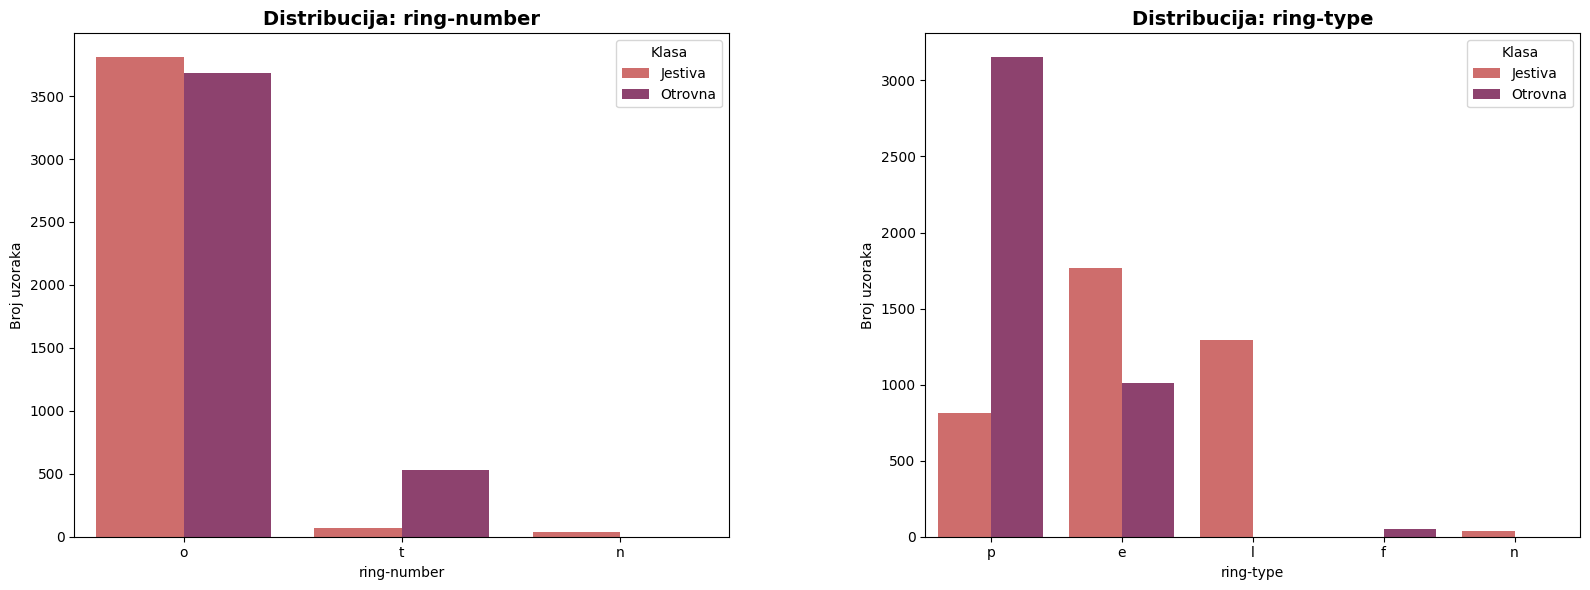

In [1648]:
ring_features = ['ring-number', 'ring-type']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(ring_features):
    sns.countplot(x=col, hue='class', data=df, palette='flare', ax=axes[i])
    
    axes[i].set_title(f'Distribucija: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].legend(title='Klasa', labels=['Jestiva', 'Otrovna'], loc='upper right')

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()

#### Distribucija ostalih atributa

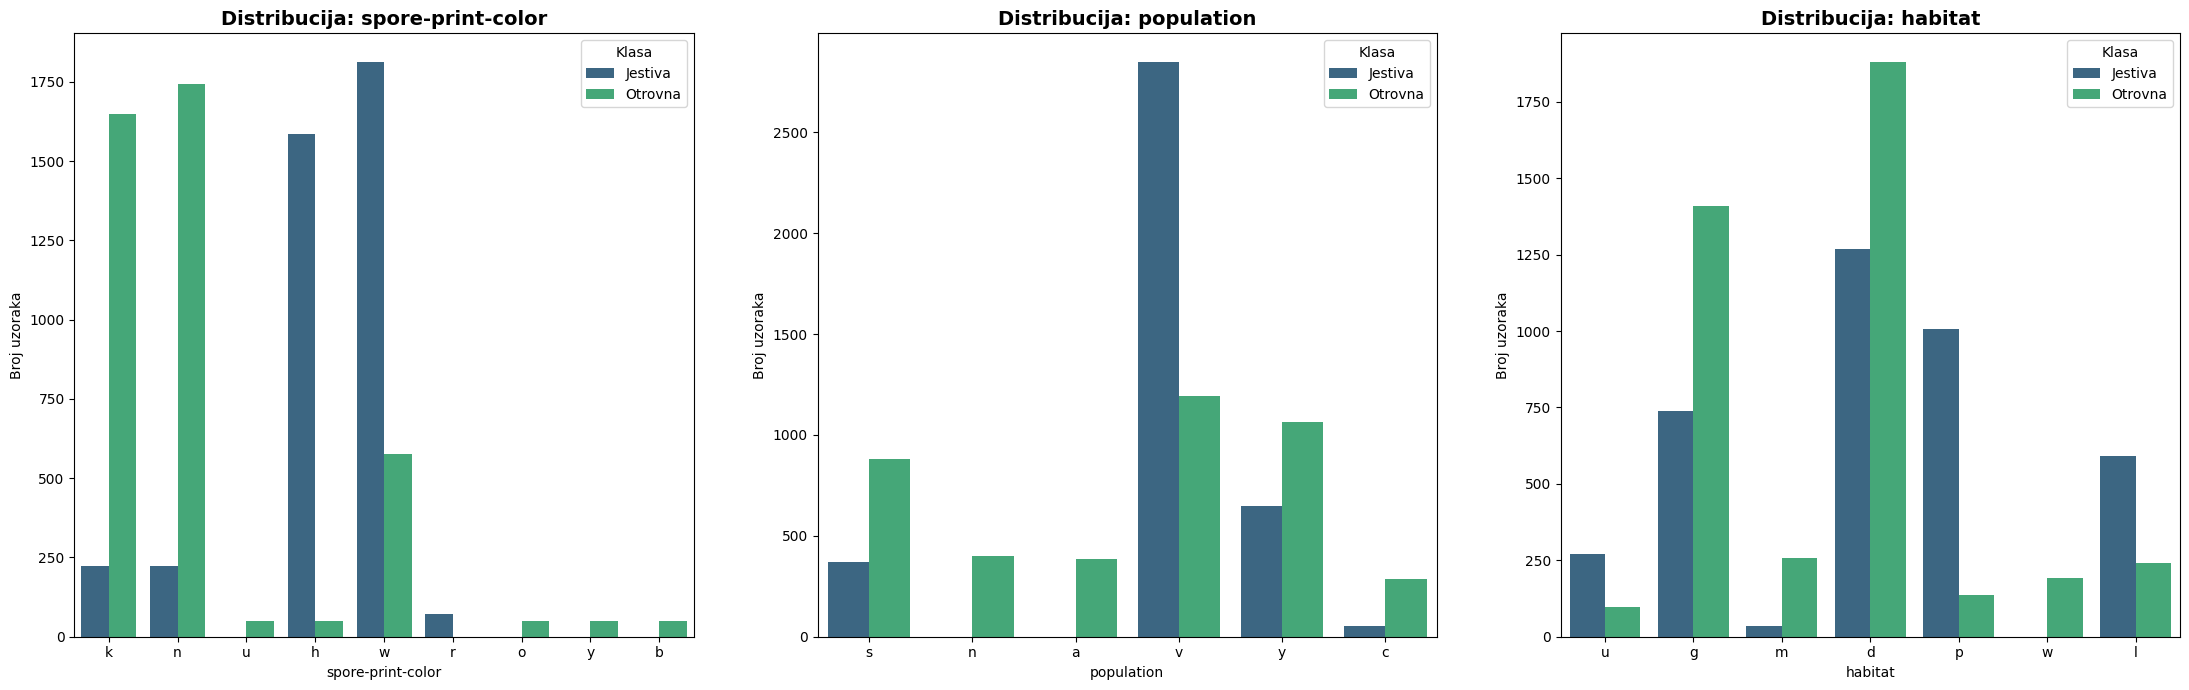

In [1649]:
misc_features = ['spore-print-color', 'population', 'habitat']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 7))
axes = axes.flatten()

for i, col in enumerate(misc_features):
    sns.countplot(x=col, hue='class', data=df, palette='viridis', ax=axes[i])
    
    axes[i].set_title(f'Distribucija: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].legend(title='Klasa', labels=['Jestiva', 'Otrovna'], loc='upper right')

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.show()

### Promene tipova podataka u integer radi prikaza heatmape

In [1650]:
df_copy = df.copy()
encoding = LabelEncoder

le = LabelEncoder()

for col in df_copy.columns:
    df_copy[col] = le.fit_transform(df_copy[col])

df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   int64
 1   cap-shape                 8124 non-null   int64
 2   cap-surface               8124 non-null   int64
 3   cap-color                 8124 non-null   int64
 4   bruises                   8124 non-null   int64
 5   odor                      8124 non-null   int64
 6   gill-attachment           8124 non-null   int64
 7   gill-spacing              8124 non-null   int64
 8   gill-size                 8124 non-null   int64
 9   gill-color                8124 non-null   int64
 10  stalk-shape               8124 non-null   int64
 11  stalk-root                8124 non-null   int64
 12  stalk-surface-above-ring  8124 non-null   int64
 13  stalk-surface-below-ring  8124 non-null   int64
 14  stalk-color-above-ring    8124 non-null 

### Prikaz toplotne mape

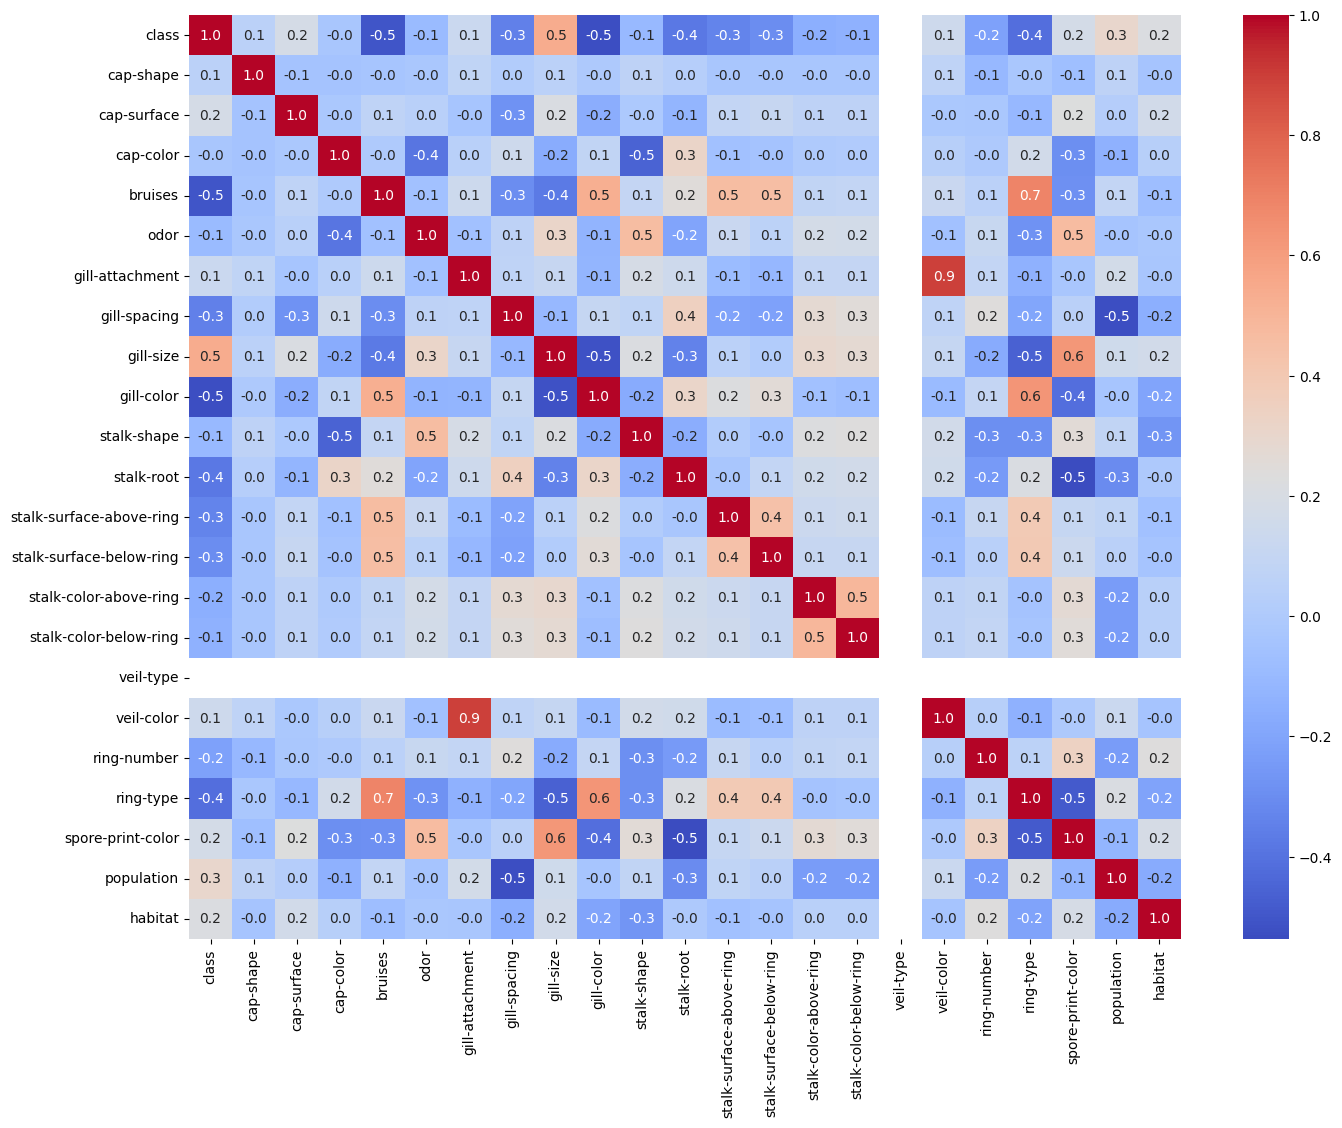

In [1651]:
plt.figure(figsize=(16, 12))

sns.heatmap(df_copy.corr(), annot=True, fmt='.1f', cmap='coolwarm')

plt.show()

Graficki prikaz jasno pokazuje da atribut veil-type (tip vela) poseduje nultu varijansu. Svih 8124 uzoraka u skupu podataka imaju identicnu vrednost ('p' - partial). Ovo nece uticati na krajnji cilj modela, zato mozemo da ga uklonimo

### Prikaz topoltne mape bez veil-type atributa

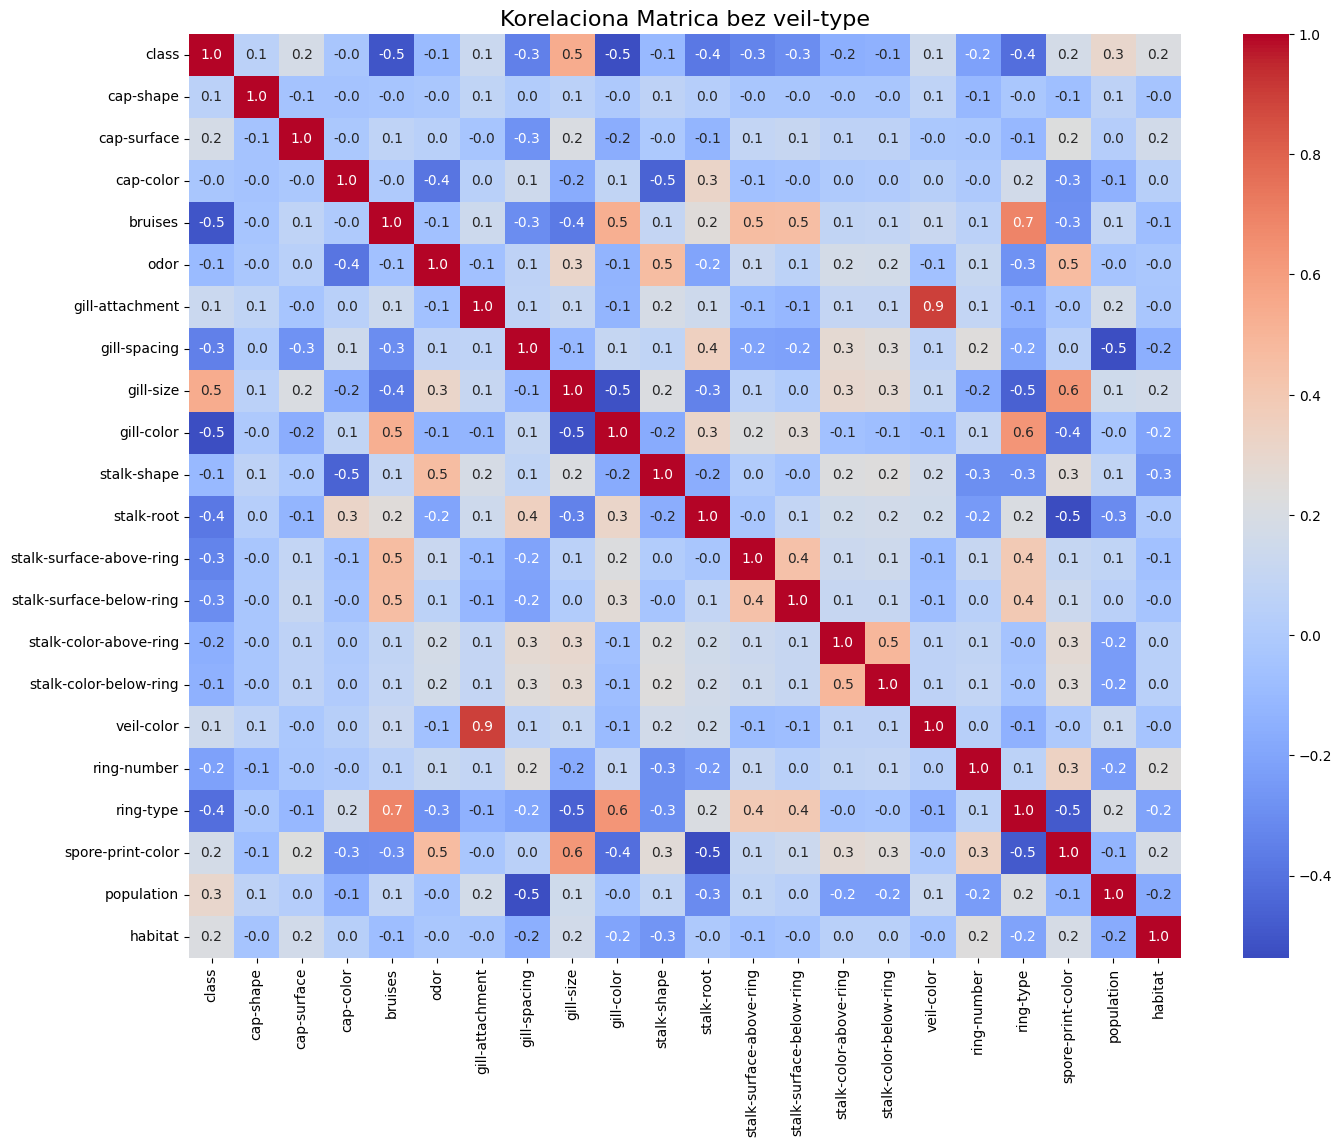

In [1652]:
df_copy = df_copy.drop('veil-type', axis=1)

plt.figure(figsize=(16, 12))
sns.heatmap(df_copy.corr(), annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Korelaciona Matrica bez veil-type', fontsize=16)

plt.show()

### Baseline provera gill-attachment atributa

In [1653]:
print("Testiranje modela sa i bez 'gill-attachment' atributa radi provere tacnosti")

df_check = pd.get_dummies(df, drop_first=True) 

X = df_check.drop('class_p', axis=1)
y = df_check['class_p']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_full = LogisticRegression(max_iter=1000)
model_full.fit(X_train, y_train)
accuracy_score_full = accuracy_score(y_test, model_full.predict(X_test))

print(f"Tacnost modela sa 'gill-attachment':  {accuracy_score_full*100:.2f}%")

cols_to_drop = [col for col in X_train.columns if 'gill-attachment' in col]
print(f"Privremeno izbacujem kolone: {cols_to_drop}")

X_train_reduced = X_train.drop(cols_to_drop, axis=1)
X_test_reduced = X_test.drop(cols_to_drop, axis=1)

model_reduced = LogisticRegression(max_iter=1000)
model_reduced.fit(X_train_reduced, y_train)
accuracy_score_reduced = accuracy_score(y_test, model_reduced.predict(X_test_reduced))

print(f"Tacnost modela bez 'gill-attachment': {accuracy_score_reduced*100:.2f}%")

diff = accuracy_score_full - accuracy_score_reduced

if diff <= 0.0001: 
    print("Razlika je 0% ili zanemarljiva.")
    print("Kolona ne doprinosi tacnosti. Moze se obrisati.")
else:
    print(f"Brisanje smanjuje tacnost za {diff*100:.2f}%.")
    print("Zadrzavamo kolonu.")

Testiranje modela sa i bez 'gill-attachment' atributa radi provere tacnosti
Tacnost modela sa 'gill-attachment':  100.00%
Privremeno izbacujem kolone: ['gill-attachment_f']
Tacnost modela bez 'gill-attachment': 100.00%
Razlika je 0% ili zanemarljiva.
Kolona ne doprinosi tacnosti. Moze se obrisati.


### Prikaz toplotne mape nakon brisanja "gill-attachment" atributa

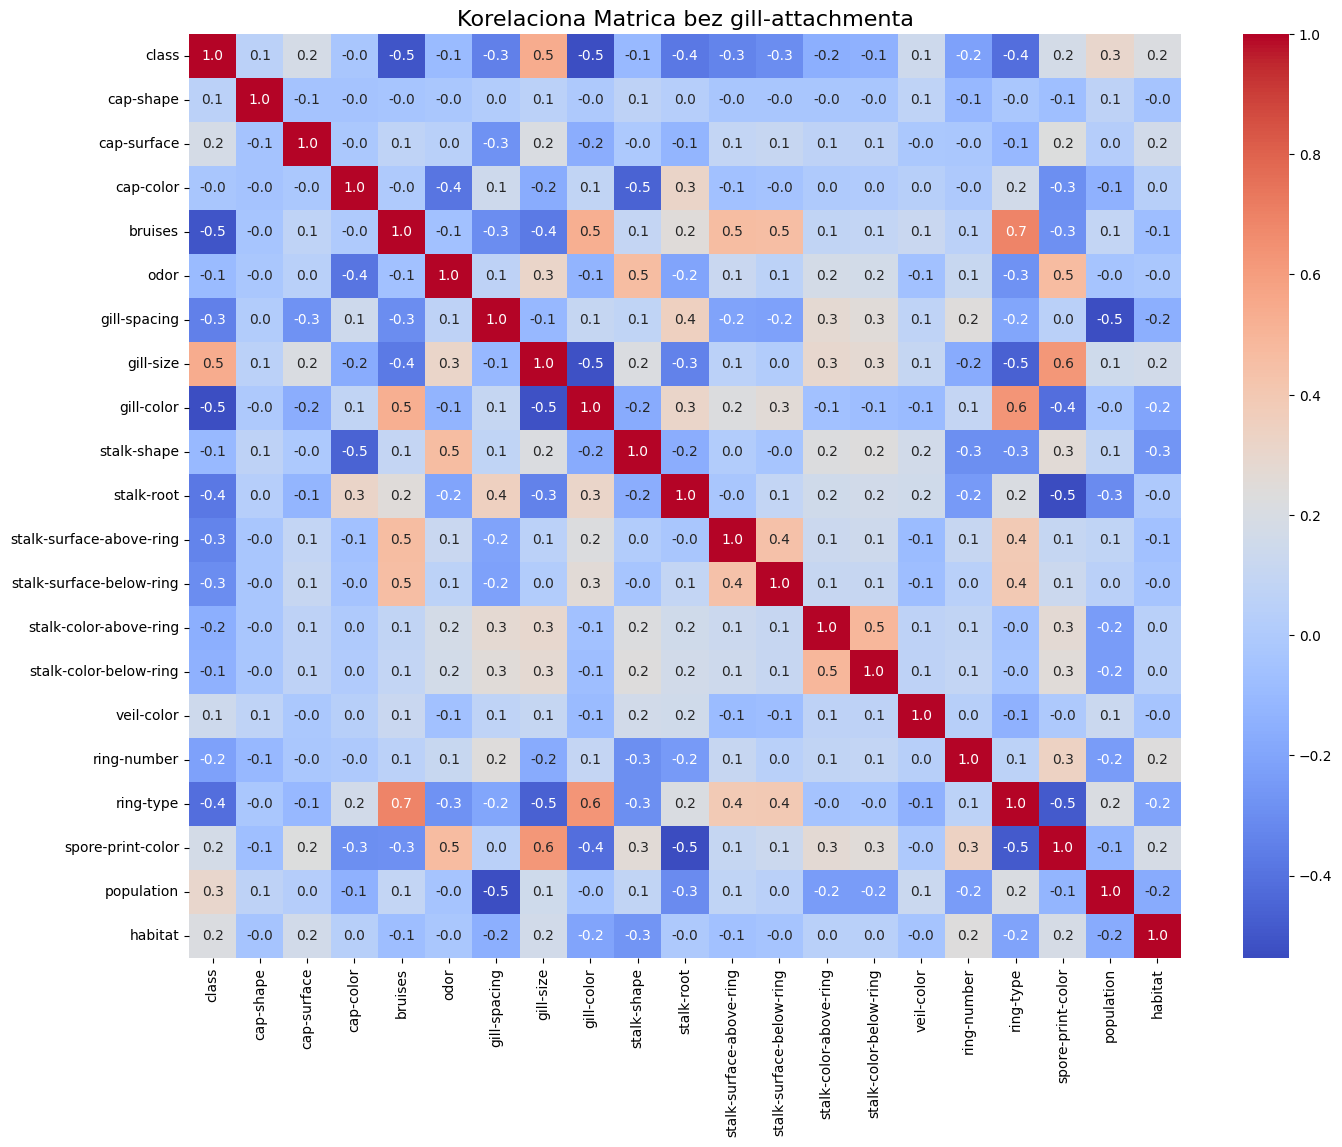

In [1654]:
df_copy = df_copy.drop('gill-attachment', axis=1)

plt.figure(figsize=(16, 12))
sns.heatmap(df_copy.corr(), annot=True, fmt='.1f', cmap='coolwarm')
plt.title('Korelaciona Matrica bez gill-attachmenta', fontsize=16)

plt.show()

### Prikaz atributa koji najvise odaju otrovnu pecurku

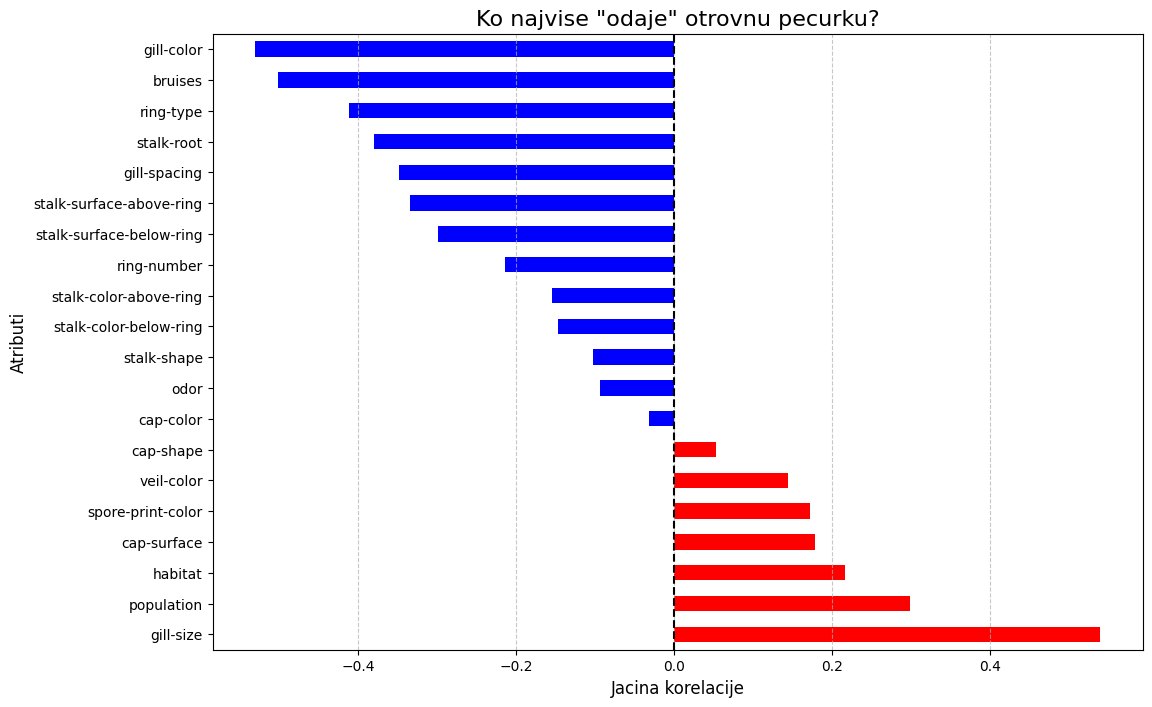

In [1655]:
target_corr = df_copy.corr()['class'].sort_values(ascending=False)

target_corr = target_corr.drop('class')

plt.figure(figsize=(12, 8))
target_corr.plot(kind='barh', color=target_corr.apply(lambda x: 'red' if x > 0 else 'blue'))

plt.title('Ko najvise "odaje" otrovnu pecurku?', fontsize=16)
plt.xlabel('Jacina korelacije', fontsize=12)
plt.ylabel('Atributi', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)

### Modifikacija originalnog skupa podataka

In [1656]:
if 'veil-type' in df.columns:
    df.drop('veil-type', axis=1, inplace=True) 
    print("Obrisan 'veil-type' iz originala.")

if 'gill-attachment' in df.columns:
    df.drop('gill-attachment', axis=1, inplace=True)
    print("Obrisan 'gill-attachment' iz originala.")

print(f"\nTrenutne dimenzije df-a: {df.shape}")


Obrisan 'veil-type' iz originala.
Obrisan 'gill-attachment' iz originala.

Trenutne dimenzije df-a: (8124, 21)


### Sistemski pregled

In [1657]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,12,2,...,4,4,9,9,4,3,5,9,6,7
top,e,x,y,n,f,n,c,b,b,t,...,s,s,w,w,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,6812,5612,1728,4608,...,5176,4936,4464,4384,7924,7488,3968,2388,4040,3148


## Modelovanje (Klasifikacija)